# Exploratory Data Analysis

This notebook performs Exploratory Data Analysis on the cleaned
AI4I Predictive Maintenance dataset.

The analysis covers:

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis
4. Target Analysis
5. Identification of patterns associated with machine failures

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
#import the cleaned dataset
from pathlib import Path

DATA_PATH = Path("../data/processed/cleaned_df.csv")
df = pd.read_csv(DATA_PATH)

In [4]:
#shape
df.shape

(10000, 7)

In [5]:
#view first 5 col
df.head()

,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [6]:
#info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   type                   10000 non-null  str    
 1   air_temperature_k      10000 non-null  float64
 2   process_temperature_k  10000 non-null  float64
 3   rotational_speed_rpm   10000 non-null  int64  
 4   torque_nm              10000 non-null  float64
 5   tool_wear_min          10000 non-null  int64  
 6   machine_failure        10000 non-null  int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 547.0 KB


# 1. Univariate Analysis

Univariate analysis examines one feature at a time to understand its distribution, central tendency, variability, frequency, and potential outliers.

The analysis includes:

- Distribution of numerical features
- Distribution of categorical features
- Outlier analysis

In [7]:
#Define Feature Groups
# Numerical features
numerical_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

# Categorical features
categorical_features = [
    "type"
]

# Binary target
target = "machine_failure"

In [8]:
# Summary statistics for numerical features
numerical_summary = df[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
air_temperature_k,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temperature_k,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed_rpm,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque_nm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear_min,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


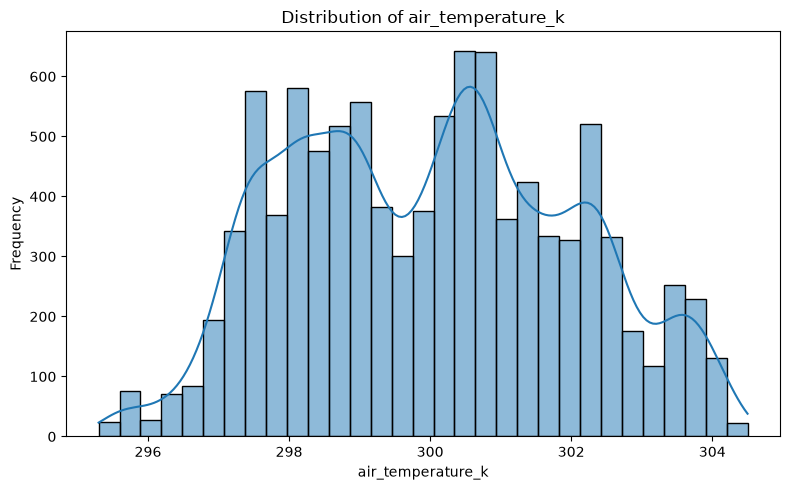

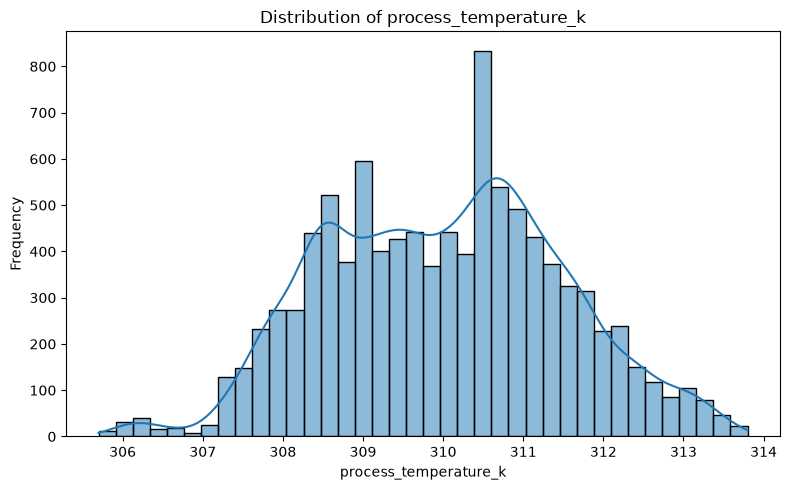

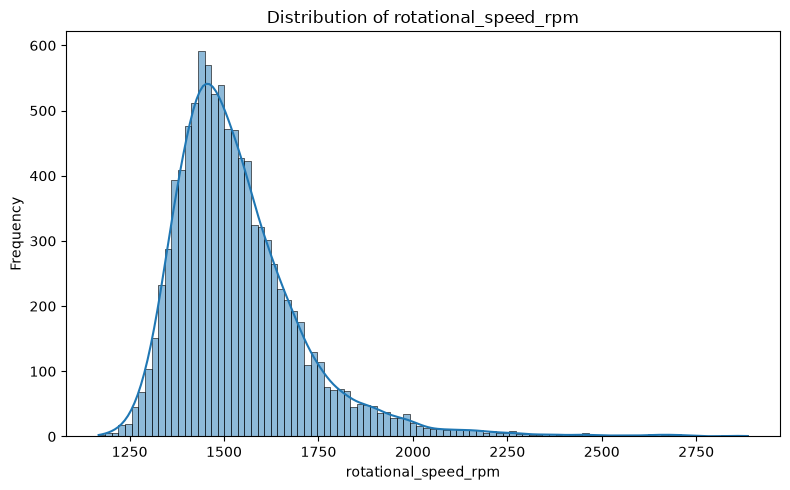

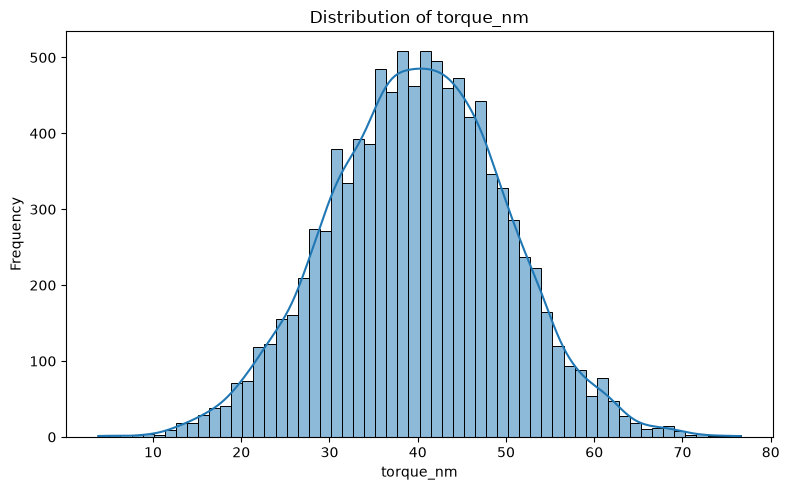

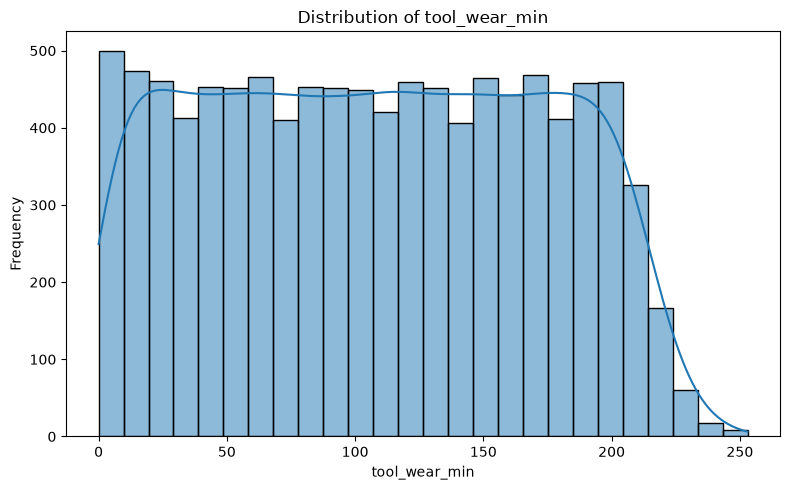

In [9]:
# Distribution of numerical features

for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [12]:
# Frequency of categorical features

for feature in categorical_features:
    print(f"\n{feature}")
    print("-" * 40)
    print(df[feature].value_counts())


type
----------------------------------------
type
L    6000
M    2997
H    1003
Name: count, dtype: int64


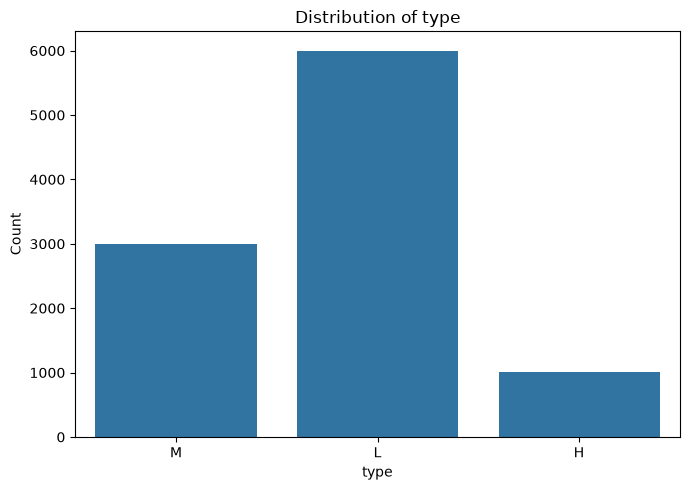

In [13]:
# Distribution of categorical features

for feature in categorical_features:
    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=feature
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [14]:
# Percentage distribution of categorical features

for feature in categorical_features:
    percentage = (
        df[feature]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print(f"\n{feature}")
    print("-" * 40)
    print(percentage)


type
----------------------------------------
type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


In [15]:
# Outlier analysis using the IQR method

outlier_summary = []

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_summary.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,air_temperature_k,298.3,301.5,3.2,293.50,306.30,0,0.00
1,process_temperature_k,308.8,311.1,2.3,305.35,314.55,0,0.00
2,rotational_speed_rpm,1423.0,1612.0,189.0,1139.50,1895.50,418,4.18
3,torque_nm,33.2,46.8,13.6,12.80,67.20,69,0.69
4,tool_wear_min,53.0,162.0,109.0,-110.50,325.50,0,0.00


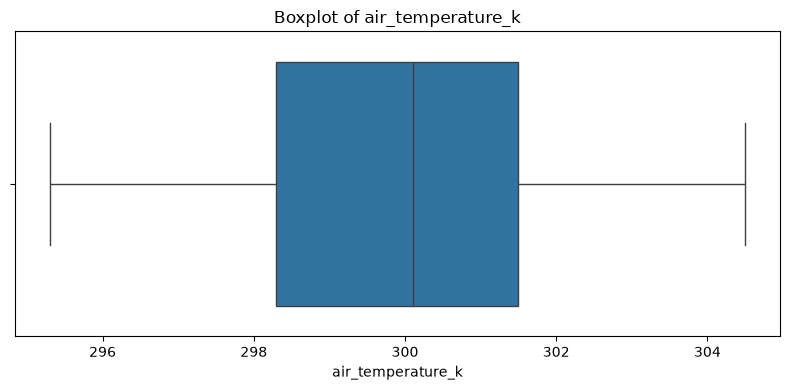

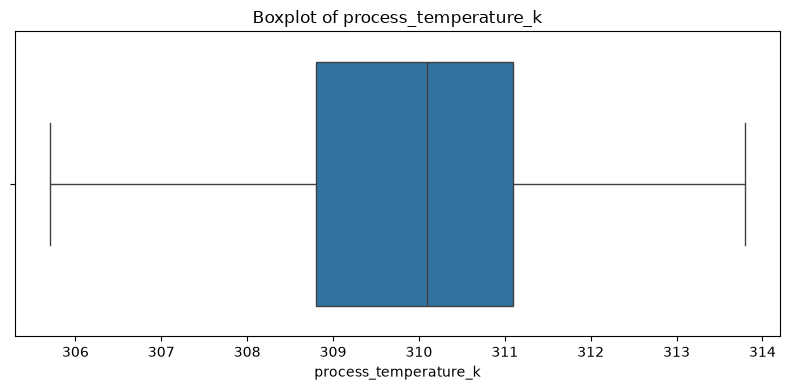

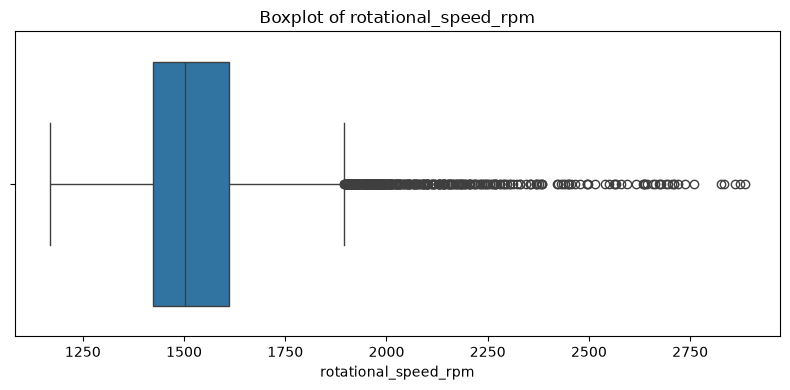

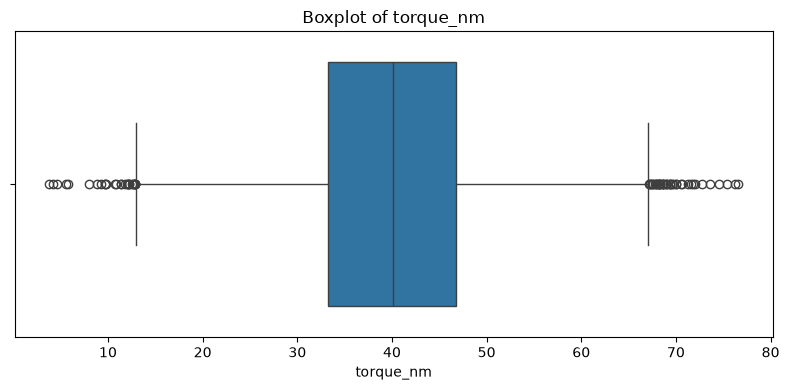

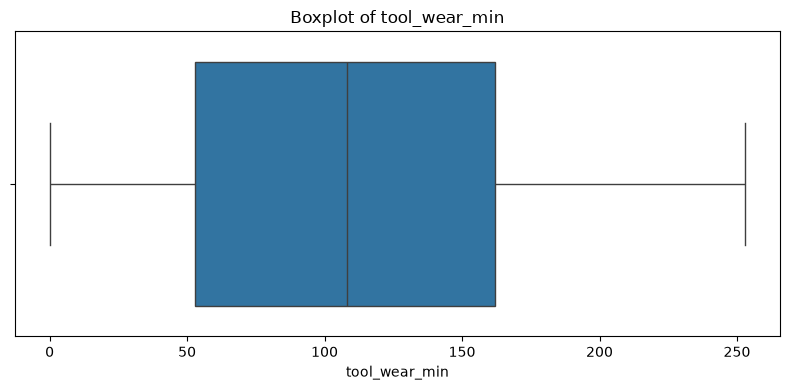

In [17]:
# Boxplots for numerical features

for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=feature
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

## 2. Bivariate Analysis

Bivariate analysis examines relationships between two variables to identify patterns associated with machine failure.

### Numerical Features vs Machine Failure

Compare the distribution of each numerical feature between failed and non-failed machines.

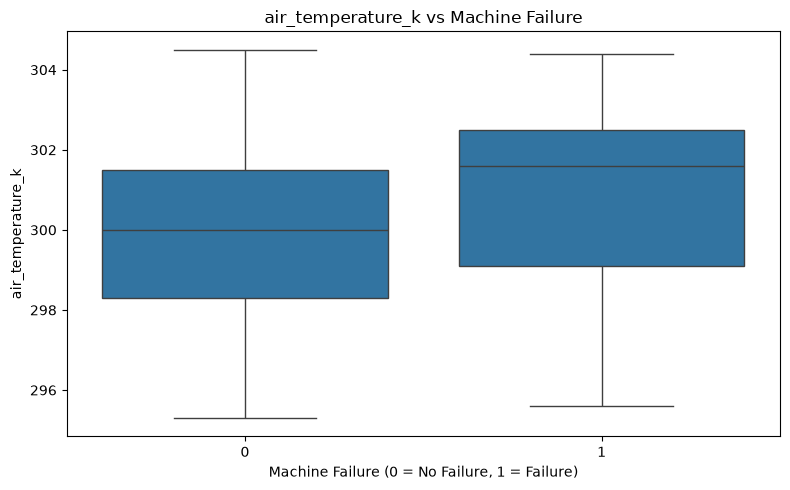

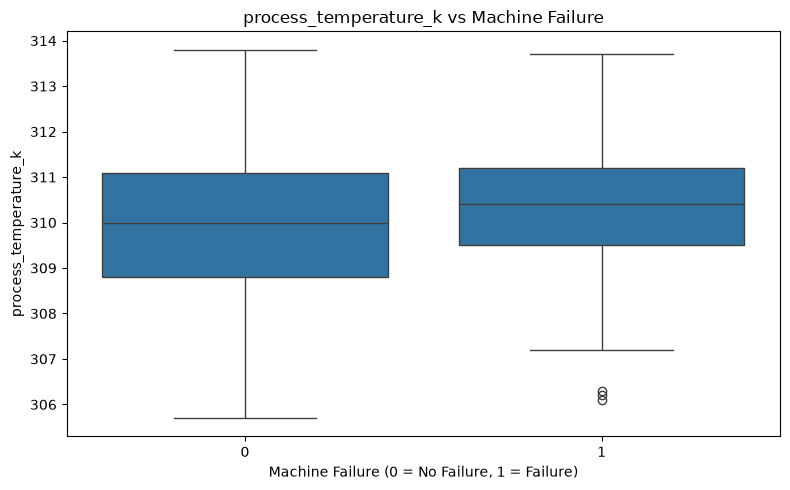

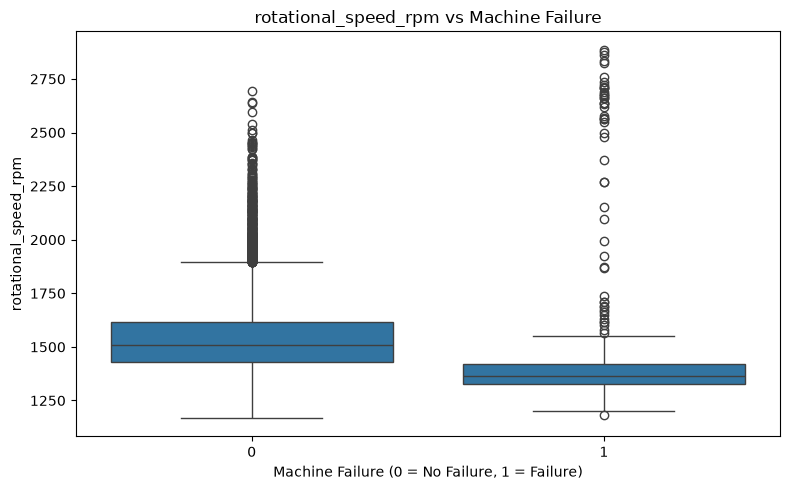

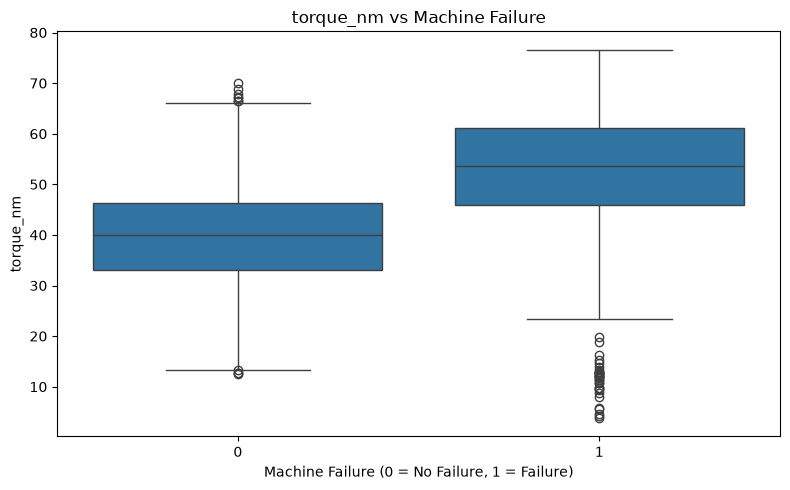

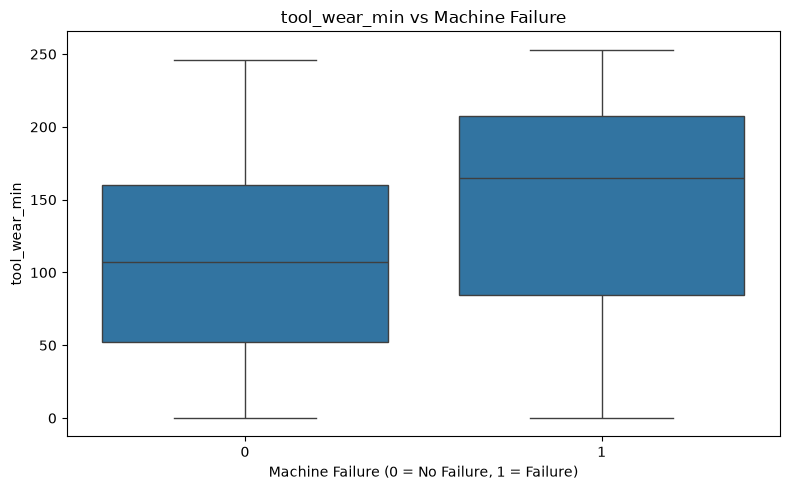

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=feature
    )

    plt.title(f'{feature} vs Machine Failure')
    plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### Numerical Feature Relationships

Examine relationships between pairs of numerical sensor features to identify linear or non-linear patterns.

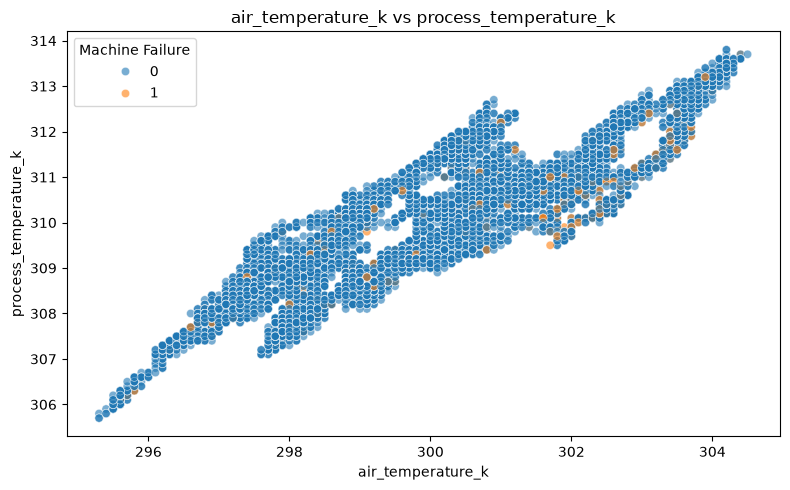

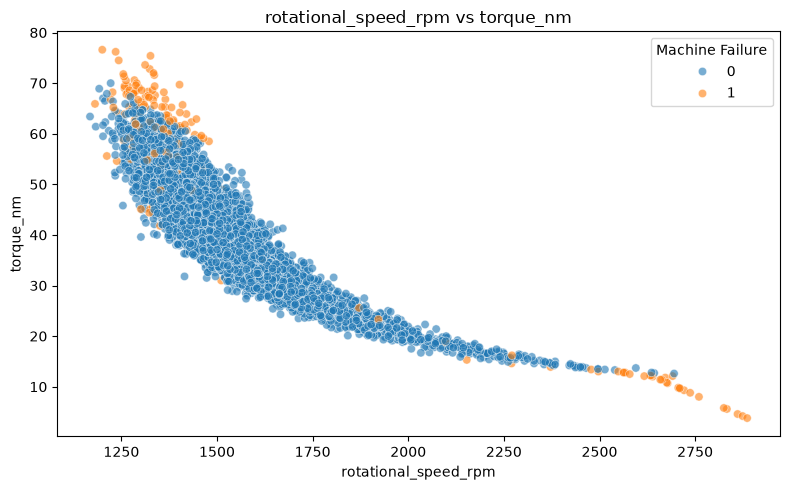

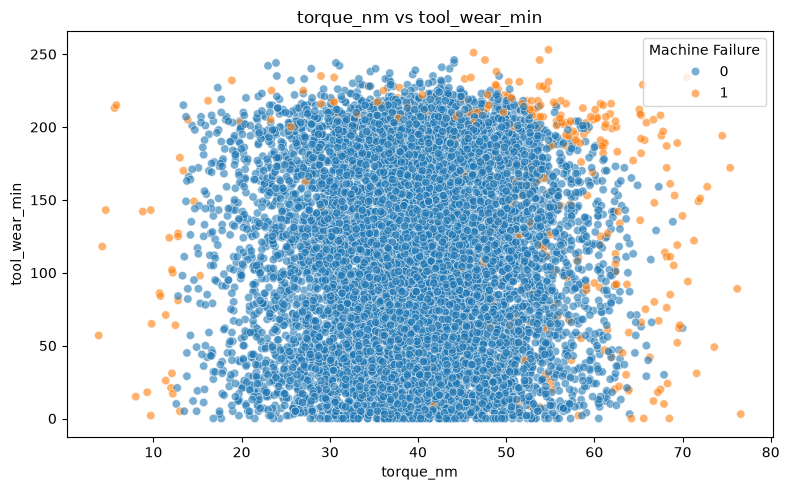

In [ ]:
feature_pairs = [
    ('air_temperature_k', 'process_temperature_k'),
    ('rotational_speed_rpm', 'torque_nm'),
    ('torque_nm', 'tool_wear_min')
]

for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue=target,
        alpha=0.6
    )

    plt.title(f'{x_feature} vs {y_feature}')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend(title='Machine Failure')
    plt.tight_layout()
    plt.show()

### Product Type vs Machine Failure

Analyze whether machine failure rates differ across machine types.

In [29]:
#Failure Count by Type
failure_by_type = pd.crosstab(
    df['type'],
    df[target]
)

failure_by_type.columns = ['No Failure', 'Failure']

failure_by_type

,No Failure,Failure
type,,
H,982,21
L,5765,235
M,2914,83


In [30]:
#Failure Rate by Type
failure_rate_by_type = (
    df.groupby('type')[target]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("Failure Rate by Machine Type (%)")
print(failure_rate_by_type.round(2))

Failure Rate by Machine Type (%)
type
L    3.92
M    2.77
H    2.09
Name: machine_failure, dtype: float64


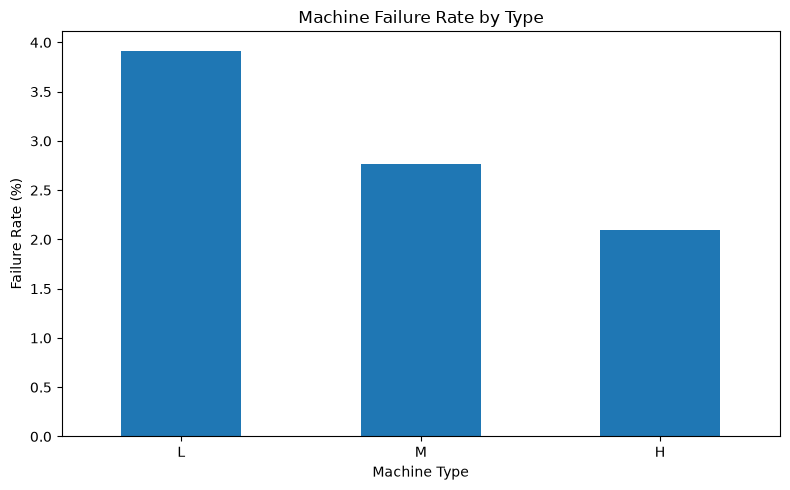

In [31]:
#Visualization
plt.figure(figsize=(8, 5))

failure_rate_by_type.plot(
    kind='bar',
    rot=0
)

plt.title('Machine Failure Rate by Type')
plt.xlabel('Machine Type')
plt.ylabel('Failure Rate (%)')
plt.tight_layout()
plt.show()

## 3.Multivariate Analysis

Multivariate analysis examines several features together to understand their combined relationships and association with machine failure.

### Correlation Analysis

Measure the linear relationship between numerical features and identify features associated with machine failure.

In [32]:
correlation_matrix = df[
    numerical_features + [target]
].corr()

correlation_matrix.round(3)

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
air_temperature_k,1.000,0.876,0.023,-0.014,0.014,0.083
process_temperature_k,0.876,1.000,0.019,-0.014,0.013,0.036
rotational_speed_rpm,0.023,0.019,1.000,-0.875,0.000,-0.044
torque_nm,-0.014,-0.014,-0.875,1.000,-0.003,0.191
tool_wear_min,0.014,0.013,0.000,-0.003,1.000,0.105
machine_failure,0.083,0.036,-0.044,0.191,0.105,1.000


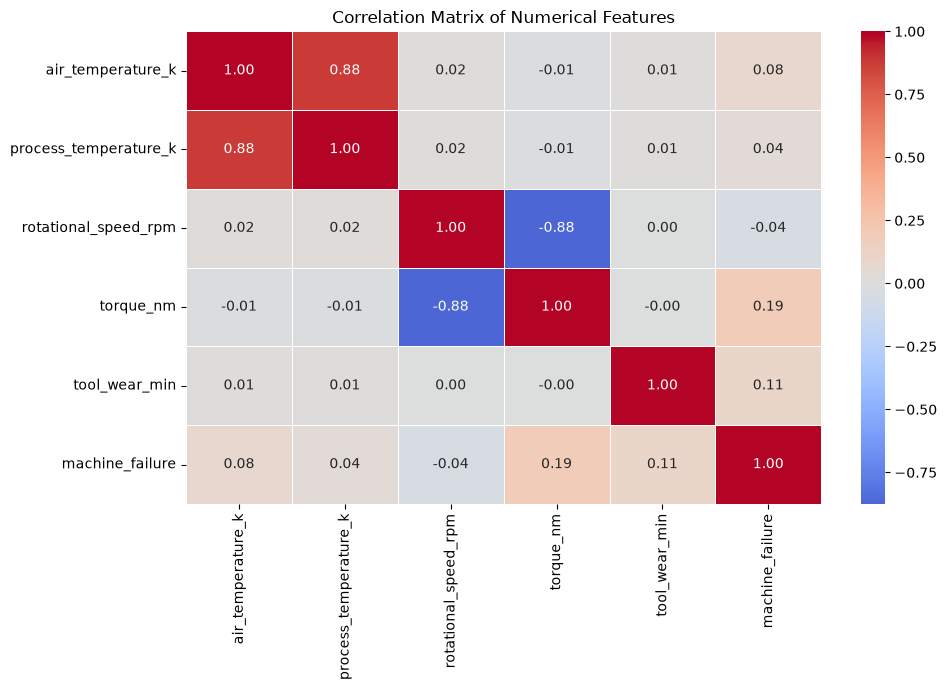

In [33]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

###  Feature Interaction with Machine Failure

Compare the average sensor and operating measurements for failed and non-failed machines.

In [34]:
#Grouped Mean Analysis
average_readings = (
    df.groupby(target)[numerical_features]
      .mean()
      .T
)

average_readings.columns = [
    'No Failure',
    'Failure'
]

average_readings

,No Failure,Failure
air_temperature_k,299.973999,300.886431
process_temperature_k,309.995570,310.290265
rotational_speed_rpm,1540.260014,1496.486726
torque_nm,39.629655,50.168142
tool_wear_min,106.693717,143.781711


<Figure size 1100x600 with 0 Axes>

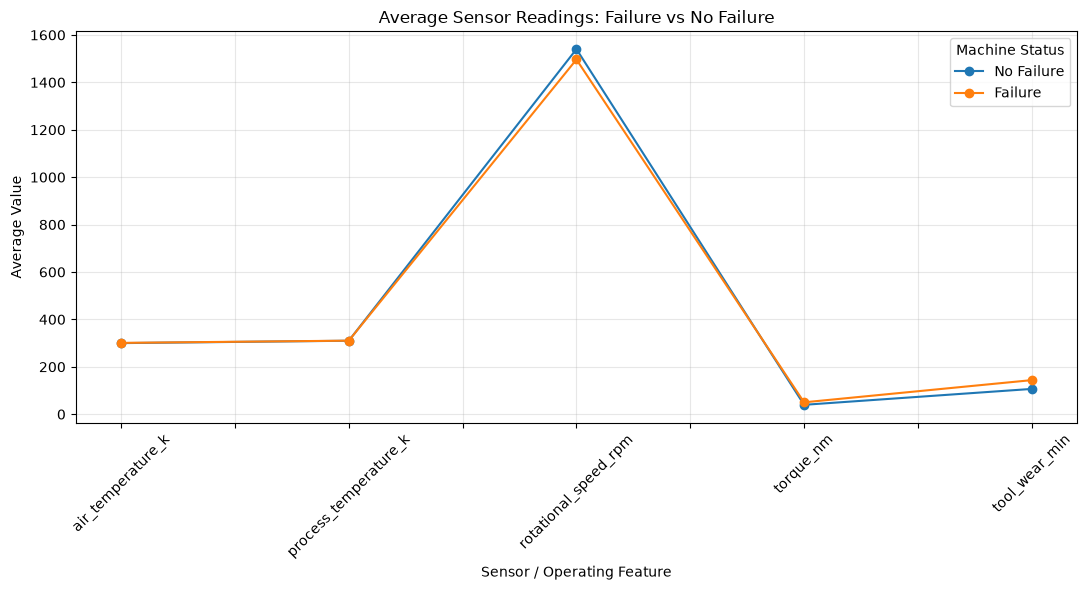

In [35]:
#Grouped Mean Visualization
plt.figure(figsize=(11, 6))

average_readings.plot(
    kind='line',
    marker='o',
    figsize=(11, 6)
)

plt.title('Average Sensor Readings: Failure vs No Failure')
plt.xlabel('Sensor / Operating Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Machine Status')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Multivariate Feature Interaction

Visualize multiple numerical features simultaneously to identify clusters or patterns associated with machine failure.

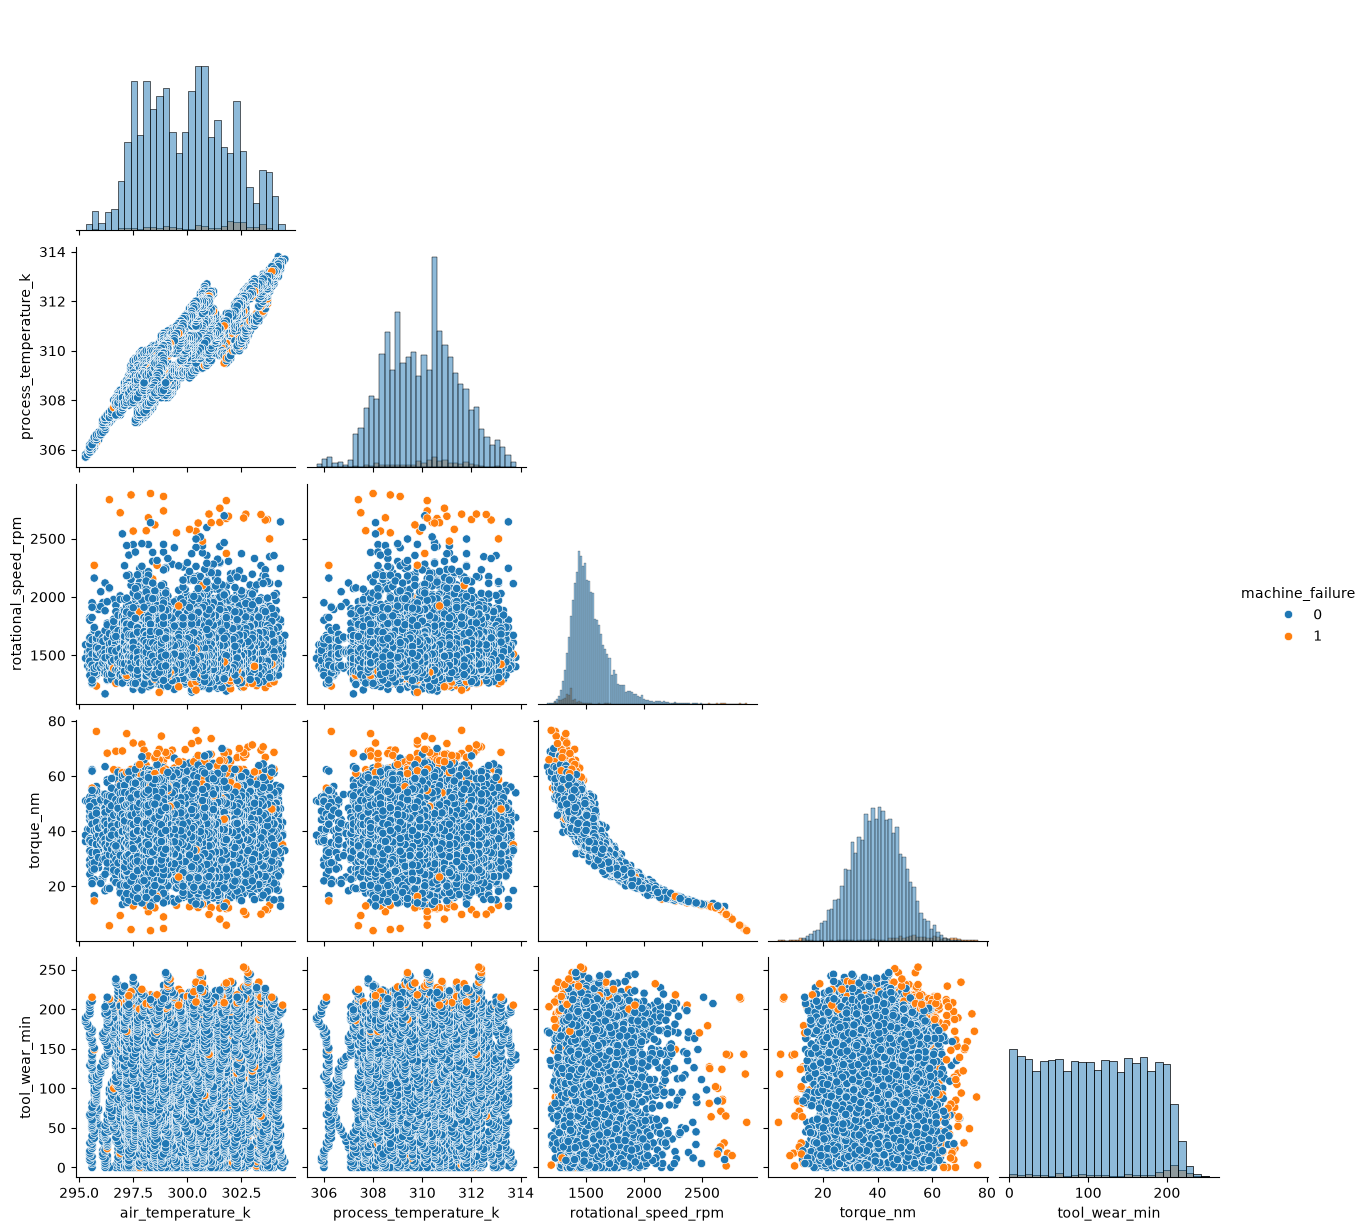

In [36]:
#Pairplot
pairplot_features = numerical_features + [target]

sns.pairplot(
    df[pairplot_features],
    hue=target,
    diag_kind='hist',
    corner=True
)

plt.show()

## 4.Target Analysis

Analyze the distribution of machine failures and identify operating patterns associated with the target variable.

### Failure vs Non-Failure

Measure the class distribution and determine whether the target is balanced.

In [38]:
#Target Counts
target_counts = df[target].value_counts().sort_index()

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': (target_counts / len(df) * 100).round(2)
})

target_summary.index = [
    'No Failure',
    'Failure'
]

target_summary

,Count,Percentage
No Failure,9661,96.61
Failure,339,3.39


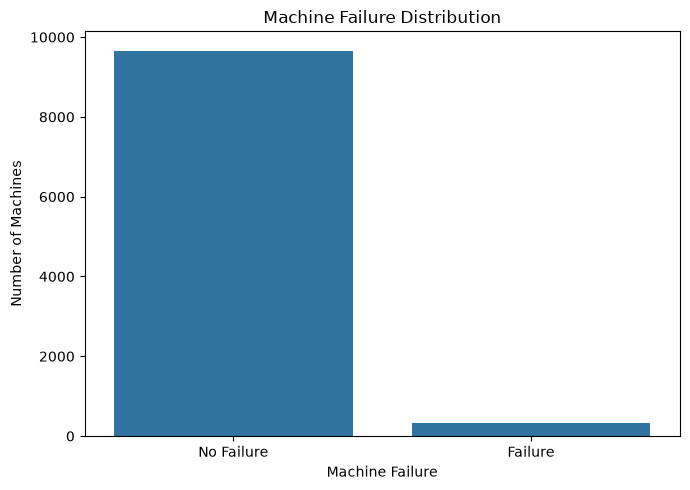

In [39]:
#Target Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure')
plt.ylabel('Number of Machines')
plt.xticks(
    [0, 1],
    ['No Failure', 'Failure']
)

plt.tight_layout()
plt.show()

### Failure Patterns

Compare operating conditions between failed and non-failed machines to identify features that show noticeable differences.

In [40]:
#Failure Rate Summary
failure_rate = df[target].mean() * 100

print(f"Overall Machine Failure Rate: {failure_rate:.2f}%")

Overall Machine Failure Rate: 3.39%


In [41]:
#Failure Pattern by Machine Type
failure_pattern = (
    df.groupby('type')[target]
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'Total Machines',
          'sum': 'Failures',
          'mean': 'Failure Rate'
      })
)

failure_pattern['Failure Rate'] = (
    failure_pattern['Failure Rate'] * 100
).round(2)

failure_pattern.sort_values(
    'Failure Rate',
    ascending=False
)

,Total Machines,Failures,Failure Rate
type,,,
L,6000,235,3.92
M,2997,83,2.77
H,1003,21,2.09


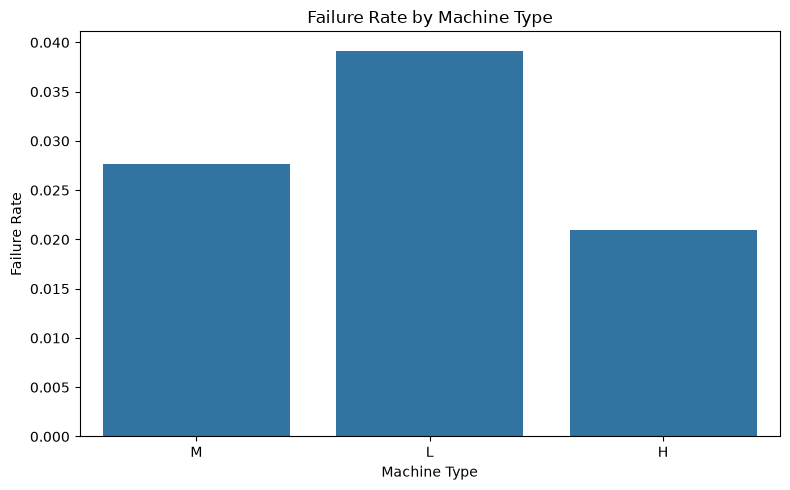

In [42]:
#Final Failure Pattern Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='type',
    y=target,
    estimator='mean',
    errorbar=None
)

plt.title('Failure Rate by Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Failure Rate')
plt.tight_layout()
plt.show()

## Final Interpretation — EDA

1. **Through the distributions, it is concluded that** the temperature and torque values are reasonably concentrated, while rotational speed is more right-skewed.

2. **Through the boxplots, it is concluded that** rotational speed and torque contain extreme observations; these may represent unusual machine operating conditions rather than errors.

3. **Through the feature-vs-failure plots, it is concluded that** machines with higher **tool wear and torque** show a greater tendency toward failure.

4. **Through the machine-type analysis, it is concluded that** the failure rate varies across machine types, with **L-type machines showing the highest failure rate** among the three types.

5. **Through the correlation analysis, it is concluded that** air temperature and process temperature are strongly related, while **rotational speed and torque have a strong inverse relationship**.

6. **Through the failure distribution, it is concluded that** machine failures are much fewer than non-failures, resulting in a **highly imbalanced target**.

7. **Overall, the EDA indicates that** machine failure is not determined by one feature alone; **tool wear, torque, rotational speed, and machine type together provide important information for predicting failures**.
